LOADING THE DATASET

In [1]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/DL_Imbalanced_dataset.csv')
df.shape

(2861800, 2)

In [2]:
df.columns

Index(['review', 'rating'], dtype='object')

In [3]:
df['review']=df['review'].astype(str).str.lower()

In [4]:
df.head(5)

,review,rating
0,note it is the canadian version i finally have...,5.0
1,its tough this is the fourth leslie sansone vi...,5.0
2,finally i have already preordered my copy of t...,5.0
3,i was swept away with the great fast service t...,5.0
4,a lot of fun judy holliday and aldo ray make f...,5.0


In [5]:
df['rating']=df['rating'].astype(int)

In [6]:
df['rating'].value_counts()

,count
rating,
5,858540
4,715450
1,572360
3,429270
2,286180


In [7]:
# Number of reviews to show per rating
n = 5

# Loop through ratings from 1 to 5
for rating in range(1, 6):
    # Filter reviews of the current rating
    filtered_reviews = df[df['rating'] == rating]['review'].dropna()

    # Sample 'n' reviews or all if fewer
    sample_reviews = filtered_reviews.sample(n=min(n, len(filtered_reviews)), random_state=rating)

    # Print the results
    print(f"\nShowing {min(n, len(filtered_reviews))} sample review(s) for Rating {rating}:\n")
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review.strip()}\n")



Showing 5 sample review(s) for Rating 1:

1. a boring let down when jp kevin bernhardt a playboy club owner buys a mysteriouslooking puzzle box and mistakes it for a work of art he has no idea that pinhead the black pope of hell doug bradley is trapped inside playing tricks on his captors mind pinhead tries his best to manipulate jp into breaking him out of his prison that is until an astute journalist terry farrell begins to suspect something watching hellraiser iii its obvious that the producers were trying to make a poor mans nightmare on elm street rather than a proper continuation of the first two films pinhead spouts bad oneliners like freddy krueger in the lesser elm street entries and a significant part of the premise even involves the hero having dreams about her fathers death the result is a watereddown unsteady film that contains only a small morsel of what made clive barkers first two hellraiser films so interesting substituting tired slasher film ingredients instead a rea

BIDIRECTIONAL LSTM

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,461 (10.15 MB)

 Trainable params: 2,659,461 (10.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
16098/16098 ━━━━━━━━━━━━━━━━━━━━ 330s 20ms/step - accuracy: 0.5786 - loss: 1.0177 - val_accuracy: 0.6330 - val_loss: 0.8773
Epoch 2/5
16098/16098 ━━━━━━━━━━━━━━━━━━━━ 394s 21ms/step - accuracy: 0.6400 - loss: 0.8625 - val_accuracy: 0.6437 - val_loss: 0.8541
Epoch 3/5
16098/16098 ━━━━━━━━━━━━━━━━━━━━ 373s 21ms/step - accuracy: 0.6573 - loss: 0.8196 - val_accuracy: 0.6442 - val_loss: 0.8512
Epoch 4/5
16098/16098 ━━━━━━━━━━━━━━━━━━━━ 328s 20ms/step - accuracy: 0.6718 - loss: 0.7863 - val_accuracy: 0.6446 - val_loss: 0.8549
Epoch 5/5
16098/16098 ━━━━━━━━━━━━━━━━━━━━ 350s 22ms/step - accuracy: 0.6843 - loss: 0.7571 - val_accuracy: 0.6418 - val_loss: 0.8662
17887/17887 ━━━━━━━━━━━━━━━━━━━━ 98s 5ms/step
Accuracy: 0.6417
Classification Report:

              precision    recall  f1-score   support

           1       0.70      0.81      0.75    114472
           2       0.43      0.22      0.29     57236
           3       0.48      0.48      0.48     85854
           4       0.60   

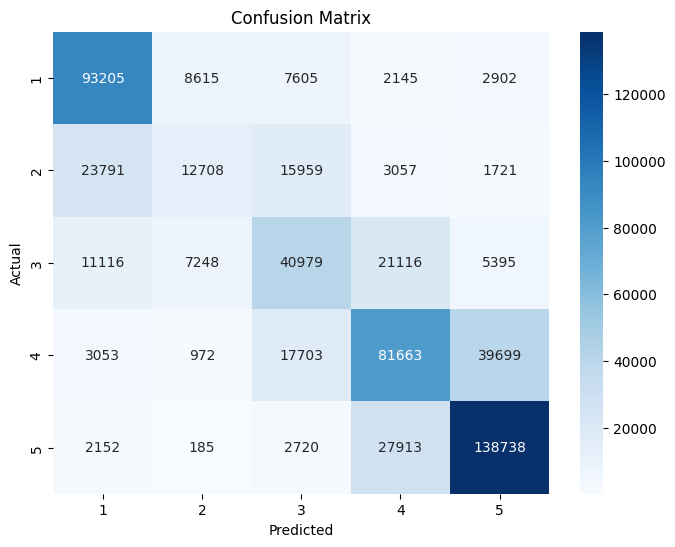

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.utils import to_categorical


# Prepare data
X = df['review']
y = df['rating']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical,
    test_size=0.2,
    stratify=y_categorical,
    random_state=42
)

# Tokenization and padding
max_words = 20000
max_len = 150

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


# Build BiLSTM Model
embedding_dim = 128
lstm_units = 64
num_classes = y_categorical.shape[1]

model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len))
model.add(Bidirectional(LSTM(lstm_units)))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Build model to show correct summary
model.build(input_shape=(None, max_len))
model.summary()

# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train Model

history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)


# Evaluate Model
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")

# Precision, Recall, F1-Score
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=[str(i) for i in le.classes_]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


SAVING THE MODEL

In [9]:
model.save('Model_A.h5')

In [10]:
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# 3. Save Label Encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)


MODEL B ON IMBALANCED DATASET

17887/17887 ━━━━━━━━━━━━━━━━━━━━ 99s 6ms/step
Accuracy: 0.5348137535816619

Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.62      0.68    114472
           2       0.30      0.52      0.38     57236
           3       0.37      0.48      0.42     85854
           4       0.51      0.47      0.49    143090
           5       0.73      0.56      0.63    171708

    accuracy                           0.53    572360
   macro avg       0.53      0.53      0.52    572360
weighted avg       0.58      0.53      0.55    572360



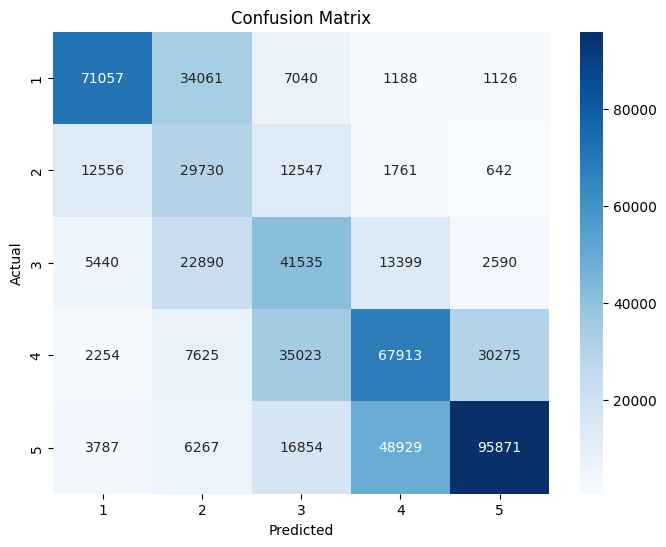

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle




X = df['review']
y = df['rating']
with open('label_encoder2.pkl', 'rb') as f:
    le = pickle.load(f)
y_encoded = le.fit_transform(y)


# --- Stratified split ---
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# --- One-hot encode (if needed for model) ---
from tensorflow.keras.utils import to_categorical
y_test = to_categorical(y_test_raw)

# --- Load model and tokenizer and label encoder ---
model = load_model('Model_B.h5')

with open('tokenizer2.pkl', 'rb') as f:
    tokenizer = pickle.load(f)





# --- Prepare test data ---
max_len = 150  # must match training
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# --- Predict ---
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_raw   # original label numeric

# --- Evaluation Metrics ---
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_.astype(str)))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
